# Prediksi AI pada Sistem IoT Monitoring Kandang Telur

Notebook ini menjelaskan alur data science / machine learning pada project IoT monitoring kandang telur.

Model yang dipakai di sistem web:
- **XGBoost Regressor** untuk prediksi jumlah telur
- **Random Forest Classifier** untuk status `Produktif`, `Perlu Dipantau`, `Afkir`
- **Isolation Forest** untuk deteksi anomali


## 1. Business Understanding

Tujuan project:
1. Memprediksi jumlah telur per sensor.
2. Menentukan status produktivitas sensor / ayam.
3. Mendeteksi anomali dari pola suhu, kelembapan, dan gas.
4. Menampilkan hasil AI ke dashboard web agar user tidak hanya melihat data mentah.


## 2. Data Understanding

Sumber data utama dari project:
- `EggEvent`
- `SensorReading`
- `GasReading`
- `SensorAiPrediction`

Pada tahap eksperimen ini, dataset dibentuk dari histori dummy yang sudah dirapikan dari **1 Januari 2026 sampai 2 Mei 2026**.


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

DATASET_CANDIDATES = [
    Path('/opt/egg-monitoring-web/artifacts/ai-dataset.json'),
    Path('/home/nashiru/egg-monitoring-work/artifacts/ai-dataset.json'),
    Path('/tmp/egg-ai-dataset.json'),
]

PREDICTION_CANDIDATES = [
    Path('/opt/egg-monitoring-web/artifacts/ai-predictions.json'),
    Path('/home/nashiru/egg-monitoring-work/artifacts/ai-predictions.json'),
    Path('/tmp/egg-ai-predictions.json'),
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(f'Tidak menemukan file dari kandidat: {paths}')

dataset_path = first_existing(DATASET_CANDIDATES)
prediction_path = first_existing(PREDICTION_CANDIDATES)

print('Dataset path :', dataset_path)
print('Prediction path:', prediction_path)


Dataset path : /tmp/egg-ai-dataset.json
Prediction path: /tmp/egg-ai-predictions.json


In [2]:
with open(dataset_path, 'r', encoding='utf-8') as f:
    dataset_payload = json.load(f)

with open(prediction_path, 'r', encoding='utf-8') as f:
    prediction_payload = json.load(f)

print('Date range  :', dataset_payload.get('dateRange'))
print('All months  :', dataset_payload.get('months'))
print('Full months :', dataset_payload.get('fullMonths'))
print('Train rows  :', len(dataset_payload.get('trainRows', [])))
print('Pred rows   :', len(dataset_payload.get('predictionRows', [])))
print('Metrics     :', prediction_payload.get('metrics'))


Date range  : {'start': '2026-01-01T00:00:00.000Z', 'end': '2026-05-02T23:59:59.999Z'}
All months  : ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Full months : ['2026-01', '2026-02', '2026-03', '2026-04']
Train rows  : 12
Pred rows   : 4
Metrics     : {'regression_mae': 0.652, 'classification_accuracy': 0.667, 'test_rows': 3}


In [3]:
train_df = pd.DataFrame([
    {
        'deviceId': row['deviceId'],
        'sensorId': row['sensorId'],
        'sourceMonth': row['sourceMonth'],
        'targetMonth': row['targetMonth'],
        **row['features'],
        'targetMonthlyEggs': row['target']['monthlyEggs'],
        'targetStatus': row['target']['status'],
    }
    for row in dataset_payload['trainRows']
])

prediction_df = pd.DataFrame([
    {
        'deviceId': row['deviceId'],
        'sensorId': row['sensorId'],
        'sourceMonth': row['sourceMonth'],
        'targetMonth': row['targetMonth'],
        **row['features'],
    }
    for row in dataset_payload['predictionRows']
])

result_df = pd.DataFrame(prediction_payload['predictions'])

train_df.head()


,deviceId,sensorId,sourceMonth,targetMonth,sensorIndex,prevMonthlyEggs,prevEggs7d,daysWithoutEgg,avgTemp30d,avgHumidity30d,gasAlertCount30d,gasAlertCount7d,rollingEggAvg2m,targetMonthlyEggs,targetStatus
0,esp32-01,A001,2026-01,2026-02,0,26,6,0,28.40,54.54,27,7,13.0,25,Produktif
1,esp32-01,A002,2026-01,2026-02,1,22,6,0,28.40,54.54,27,7,11.0,21,Perlu Dipantau
2,esp32-01,B001,2026-01,2026-02,2,16,4,0,28.40,54.54,27,7,8.0,16,Afkir
3,esp32-01,B002,2026-01,2026-02,3,11,3,0,28.40,54.54,27,7,5.5,10,Afkir
4,esp32-01,A001,2026-02,2026-03,0,25,6,0,28.42,54.79,27,10,12.5,24,Produktif


### Ringkasan Data Training

Di sini terlihat bahwa setiap baris mewakili **1 sensor pada 1 bulan sumber**, lalu targetnya adalah **bulan berikutnya**.


In [4]:
train_df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
deviceId,12,1,esp32-01,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensorId,12,4,A001,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sourceMonth,12,3,2026-01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
targetMonth,12,3,2026-02,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensorIndex,12.0,NaN,NaN,NaN,1.5,1.167748,0.0,0.75,1.5,2.25,3.0
prevMonthlyEggs,12.0,NaN,NaN,NaN,17.916667,5.946096,9.0,14.0,18.0,22.5,26.0
prevEggs7d,12.0,NaN,NaN,NaN,4.333333,1.370689,2.0,3.0,4.5,5.25,6.0
daysWithoutEgg,12.0,NaN,NaN,NaN,0.083333,0.288675,0.0,0.0,0.0,0.0,1.0
avgTemp30d,12.0,NaN,NaN,NaN,28.423333,0.021462,28.4,28.4,28.42,28.45,28.45
avgHumidity30d,12.0,NaN,NaN,NaN,54.7,0.118475,54.54,54.54,54.77,54.79,54.79


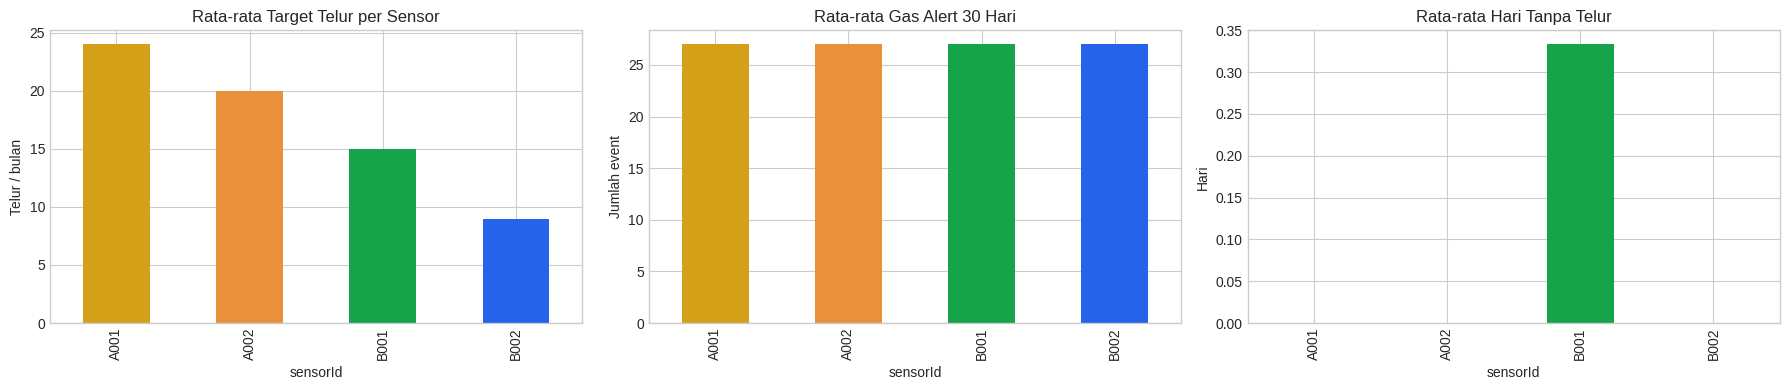

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

train_df.groupby('sensorId')['targetMonthlyEggs'].mean().plot(kind='bar', ax=axes[0], color=['#D4A017', '#E8913A', '#16A34A', '#2563EB'])
axes[0].set_title('Rata-rata Target Telur per Sensor')
axes[0].set_ylabel('Telur / bulan')

train_df.groupby('sensorId')['gasAlertCount30d'].mean().plot(kind='bar', ax=axes[1], color=['#D4A017', '#E8913A', '#16A34A', '#2563EB'])
axes[1].set_title('Rata-rata Gas Alert 30 Hari')
axes[1].set_ylabel('Jumlah event')

train_df.groupby('sensorId')['daysWithoutEgg'].mean().plot(kind='bar', ax=axes[2], color=['#D4A017', '#E8913A', '#16A34A', '#2563EB'])
axes[2].set_title('Rata-rata Hari Tanpa Telur')
axes[2].set_ylabel('Hari')

plt.tight_layout()
plt.show()


## 3. Data Preparation

Tahap preprocessing yang dilakukan pada project ini:
- filter tanggal `2026-01-01` sampai `2026-05-02`
- kelompokkan data per bulan dan per sensor
- bulan yang belum penuh, seperti Mei yang baru 2 hari, **tidak dipakai sebagai target training**
- hasilnya dibagi menjadi:
  - `trainRows`
  - `predictionRows`


In [6]:
print('Bulan penuh untuk training:', dataset_payload['fullMonths'])
print('\nContoh prediction rows:')
prediction_df


Bulan penuh untuk training: ['2026-01', '2026-02', '2026-03', '2026-04']

Contoh prediction rows:


,deviceId,sensorId,sourceMonth,targetMonth,sensorIndex,prevMonthlyEggs,prevEggs7d,daysWithoutEgg,avgTemp30d,avgHumidity30d,gasAlertCount30d,gasAlertCount7d,rollingEggAvg2m
0,esp32-01,A001,2026-04,2026-05,0,23,5,0,28.38,54.6,31,5,24
1,esp32-01,A002,2026-04,2026-05,1,19,5,0,28.38,54.6,31,5,20
2,esp32-01,B001,2026-04,2026-05,2,14,3,1,28.38,54.6,31,5,15
3,esp32-01,B002,2026-04,2026-05,3,8,2,0,28.38,54.6,31,5,9


## 4. Feature Engineering

Feature engineering dilakukan untuk mengubah data mentah menjadi variabel yang lebih berguna bagi model.

Fitur yang dipakai model di project ini:
- `sensorIndex`
- `prevMonthlyEggs`
- `prevEggs7d`
- `daysWithoutEgg`
- `avgTemp30d`
- `avgHumidity30d`
- `gasAlertCount30d`
- `gasAlertCount7d`
- `rollingEggAvg2m`

Target yang dipelajari model:
- `targetMonthlyEggs` untuk regresi
- `targetStatus` untuk klasifikasi


In [ ]:
feature_cols = [
    'sensorIndex',
    'prevMonthlyEggs',
    'prevEggs7d',
    'daysWithoutEgg',
    'avgTemp30d',
    'avgHumidity30d',
    'gasAlertCount30d',
    'gasAlertCount7d',
    'rollingEggAvg2m',
]

feature_summary = train_df[feature_cols + ['targetMonthlyEggs']].corr().round(2)
feature_summary


## 5. Modeling

Pada notebook ini, proses modeling diperlihatkan secara eksplisit agar alurnya jelas.

Model yang digunakan:
1. **XGBoost Regressor** untuk memprediksi `targetMonthlyEggs`
2. **Random Forest Classifier** untuk memprediksi `targetStatus`
3. **Isolation Forest** untuk mendeteksi pola anomali

Urutan proses modeling:
1. bentuk matriks fitur `X`
2. bentuk target regresi `y_reg`
3. bentuk target klasifikasi `y_cls`
4. bagi data menjadi `train` dan `test`
5. latih masing-masing model
6. evaluasi hasil prediksi


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report, confusion_matrix
from xgboost import XGBRegressor
import seaborn as sns

STATUS_TO_INT = {'Afkir': 0, 'Perlu Dipantau': 1, 'Produktif': 2}
INT_TO_STATUS = {v: k for k, v in STATUS_TO_INT.items()}
RANDOM_STATE = 42

X = train_df[feature_cols].copy()
y_reg = train_df['targetMonthlyEggs'].astype(float)
y_cls = train_df['targetStatus'].map(STATUS_TO_INT)

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print('Shape X        :', X.shape)
print('Shape X_train  :', X_train.shape)
print('Shape X_test   :', X_test.shape)
print('Target regresi :', y_reg.name)
print('Target kelas   :', sorted(train_df['targetStatus'].unique()))


In [ ]:
xgb_regressor = XGBRegressor(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE,
)

iforest_model = IsolationForest(
    n_estimators=150,
    contamination=0.2,
    random_state=RANDOM_STATE,
)

xgb_regressor.fit(X_train, y_reg_train)
rf_classifier.fit(X_train, y_cls_train)
iforest_model.fit(X_train)

print('Training model selesai.')


## 6. Model Evaluation

Evaluasi dilakukan pada data `X_test` yang tidak dipakai saat training.

Metrik yang digunakan:
- **MAE** untuk XGBoost Regressor
- **Accuracy** untuk Random Forest Classifier
- **Anomaly score** untuk Isolation Forest

Karena dataset project ini kecil, fokus evaluasi adalah menunjukkan bahwa alur model berjalan dengan benar dan outputnya masuk akal terhadap pola data.


In [ ]:
reg_pred = xgb_regressor.predict(X_test)
cls_pred = rf_classifier.predict(X_test)
anomaly_raw = iforest_model.score_samples(X_test)

reg_mae = mean_absolute_error(y_reg_test, reg_pred)
cls_acc = accuracy_score(y_cls_test, cls_pred)

metrics_df = pd.DataFrame([
    {'model': 'XGBoost Regressor', 'metric': 'MAE', 'score': reg_mae},
    {'model': 'Random Forest Classifier', 'metric': 'Accuracy', 'score': cls_acc},
])

print('MAE regresi      :', round(reg_mae, 3))
print('Accuracy klasif. :', round(cls_acc, 3))
print('
Classification report:')
print(
    classification_report(
        y_cls_test,
        cls_pred,
        labels=[0, 1, 2],
        target_names=['Afkir', 'Perlu Dipantau', 'Produktif'],
        zero_division=0,
    )
)

metrics_df


In [ ]:
eval_df = X_test.copy()
eval_df['actualMonthlyEggs'] = y_reg_test.values
eval_df['predictedMonthlyEggs'] = np.round(reg_pred, 1)
eval_df['actualStatus'] = y_cls_test.map(INT_TO_STATUS).values
eval_df['predictedStatus'] = [INT_TO_STATUS[int(v)] for v in cls_pred]
eval_df['anomalyScoreRaw'] = anomaly_raw

eval_df[['actualMonthlyEggs', 'predictedMonthlyEggs', 'actualStatus', 'predictedStatus', 'anomalyScoreRaw']]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=metrics_df, x='model', y='score', hue='metric', ax=axes[0])
axes[0].set_title('Ringkasan Metrik Evaluasi')
axes[0].set_ylim(0, max(1.0, metrics_df['score'].max() + 0.2))
axes[0].tick_params(axis='x', rotation=15)

cm = confusion_matrix(y_cls_test, cls_pred, labels=[0, 1, 2])
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Afkir', 'Perlu Dipantau', 'Produktif'],
    yticklabels=['Afkir', 'Perlu Dipantau', 'Produktif'],
    ax=axes[1],
)
axes[1].set_title('Confusion Matrix Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 7. Feature Importance

Feature importance membantu menjelaskan fitur mana yang paling berpengaruh terhadap keputusan model.

Di sini ditampilkan importance dari:
- **Random Forest Classifier**
- **XGBoost Regressor**


In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'rf_importance': rf_classifier.feature_importances_,
    'xgb_importance': xgb_regressor.feature_importances_,
}).sort_values('rf_importance', ascending=False)

importance_df


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=importance_df, x='rf_importance', y='feature', ax=axes[0], color='#59A14F')
axes[0].set_title('Feature Importance - Random Forest')

sns.barplot(data=importance_df.sort_values('xgb_importance', ascending=False), x='xgb_importance', y='feature', ax=axes[1], color='#E15759')
axes[1].set_title('Feature Importance - XGBoost')

plt.tight_layout()
plt.show()


## 8. Deployment ke Web

Notebook ini menunjukkan proses modeling secara akademik.

Sedangkan di sistem produksi, alurnya adalah:
1. `export-ai-dataset.ts` membentuk dataset dari database
2. `train-ai-models.py` melatih model dan menghasilkan `ai-predictions.json`
3. `import-ai-predictions.ts` memasukkan hasil ke tabel `SensorAiPrediction`
4. Web membaca data melalui API:
   - `/api/ai/predictions`
   - `/api/ai/actions`
5. Hasil tampil di:
   - Dashboard
   - Sensor Log
   - Riwayat Telur
   - Halaman Prediksi AI


In [ ]:
print('Model version pipeline produksi:', prediction_payload.get('modelVersion'))
print('Metrics pipeline produksi:', prediction_payload.get('metrics'))

result_df[['sensorId', 'predictedEggs7d', 'predictedMonthlyEggs', 'predictedStatus', 'confidence', 'afkirRiskScore', 'anomalyLabel']]


## Kesimpulan

Sekarang notebook ini memperlihatkan dua hal sekaligus:
1. **proses machine learning** secara eksplisit, mulai dari pembentukan `X` dan `y`, training, evaluasi, sampai feature importance
2. **hubungan dengan sistem produksi**, yaitu bagaimana hasil model masuk kembali ke web dashboard

Dengan begitu, notebook ini lebih dekat ke format notebook data science yang biasa dipakai untuk presentasi dan laporan.
